# Magnetic Resonance Imaging - 361.2.6501
## Final Project: Central-Slice Brain Tumor Segmentation

**Students:** Yuval Ratzabi (ID: TODO), Second student (ID: TODO)

This notebook is the complete executable project report. It performs binary whole-tumor segmentation using only axial slice 80 from T1, T1ce, T2 and FLAIR. No neighbouring slices or full-volume features are used.

## Abstract

We compare a classical raw-intensity Gaussian Mixture Model (GMM) baseline with four advanced variations: relative brain-boundary distance, bilateral hemispheric symmetry, hierarchical modality evidence, and a fully combined model. All GMM likelihoods are evaluated in log space. Candidate regions are obtained directly from connected tumor-posterior support rather than requiring closed Sobel contours. Image-processing parameters are selected once on the baseline validation predictions and frozen; advanced models tune probabilistic parameters only. Replace this paragraph's final sentences with the conclusions after the final run.

## 1. Experimental design

- Dataset: BraTS 2020 course HDF5 representation.
- Input: T1, T1ce, T2 and FLAIR from slice 80.
- Target: binary whole tumor.
- Split: frozen randomized patient-level 250/50/69 split, stratified by central-slice tumor presence and size.
- Selection: validation set only.
- Final test: evaluated once after all parameters are frozen.

Models:

1. **Raw (4D):** log-space GMM baseline.
2. **Boundary distance (5D):** baseline modalities plus relative distance from the 2D brain boundary.
3. **Symmetry (8D):** baseline modalities plus four bilateral NDI features.
4. **Hierarchical modalities:** baseline plus FLAIR/T2 whole-tumor and T1/T1ce core evidence branches.
5. **Combined:** 9D intensity/distance/symmetry GMM plus hierarchical evidence.

In [ ]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

from config import *
from data.preprocessing import build_features, load_preprocessed_slice
from data.splits import create_splits
from evaluation.evaluate import evaluate_model, prepare_evidence_cache, save_evaluation
from evaluation.optimization import (
    load_selected_parameters,
    optimize_advanced_model,
    optimize_baseline,
    save_selected_parameters,
)
from evaluation.visualizations import (
    choose_qualitative_examples,
    plot_metric_boxplots,
    plot_pipeline_diagnostic,
    plot_qualitative_examples,
    plot_required_scatterplots,
)
from models.training import train_or_load_models

%matplotlib inline
sns.set_theme(style="whitegrid")
for directory in (MODEL_DIR, VALIDATION_OUTPUT_DIR, TEST_OUTPUT_DIR, FIGURES_DIR, DIAGNOSTICS_DIR):
    Path(directory).mkdir(parents=True, exist_ok=True)

N_BASELINE_TRIALS = 60
N_ADVANCED_TRIALS = 50
FORCE_NEW_SPLIT = False
FORCE_RETRAIN_MODELS = False
REUSE_SELECTED_PARAMETERS = True

## 2. Patient splits

The split manifests are created once and then reused. Regeneration requires explicitly setting `FORCE_NEW_SPLIT=True`.

In [7]:
splits = create_splits(force=FORCE_NEW_SPLIT)
split_rows = []
for split_name, volume_ids in splits.items():
    split_frame = pd.read_csv(SPLITS_DIR / f"{split_name}_ids.csv")
    split_rows.append({
        "Split": split_name,
        "Patients": len(split_frame),
        "Tumor-present slice 80": int((split_frame["tumor_pixels"] > 0).sum()),
        "Tumor-free slice 80": int((split_frame["tumor_pixels"] == 0).sum()),
        "Median tumor pixels": float(split_frame.loc[split_frame["tumor_pixels"] > 0, "tumor_pixels"].median()),
    })
split_summary = pd.DataFrame(split_rows)
display(split_summary)

,Split,Patients,Tumor-present slice 80,Tumor-free slice 80,Median tumor pixels
0,train,250,223,27,1797.0
1,validation,50,45,5,1794.0
2,test,69,62,7,1692.5


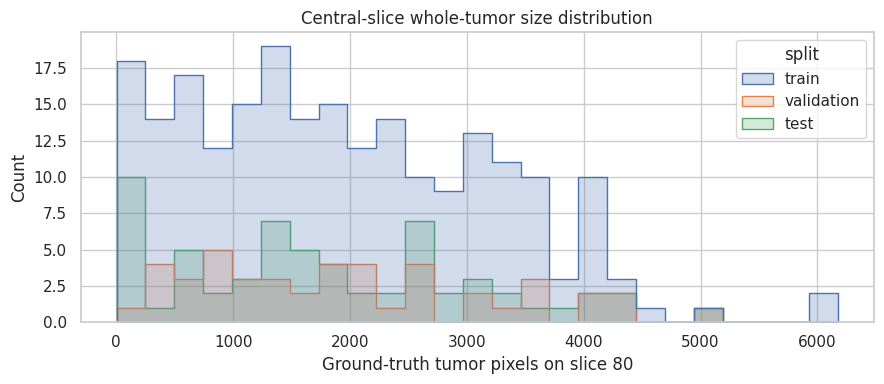

In [8]:
all_split_data = pd.concat([
    pd.read_csv(SPLITS_DIR / f"{name}_ids.csv").assign(split=name)
    for name in ("train", "validation", "test")
], ignore_index=True)
plt.figure(figsize=(9, 4))
sns.histplot(data=all_split_data[all_split_data["tumor_pixels"] > 0], x="tumor_pixels", hue="split", bins=25, element="step", common_norm=False)
plt.title("Central-slice whole-tumor size distribution")
plt.xlabel("Ground-truth tumor pixels on slice 80")
plt.tight_layout()
plt.show()

## 3. MRI-specific preprocessing

Every modality is Z-score normalized using only nonzero brain pixels from the same central slice. Relative distance and bilateral symmetry are also calculated only on this 2D slice.

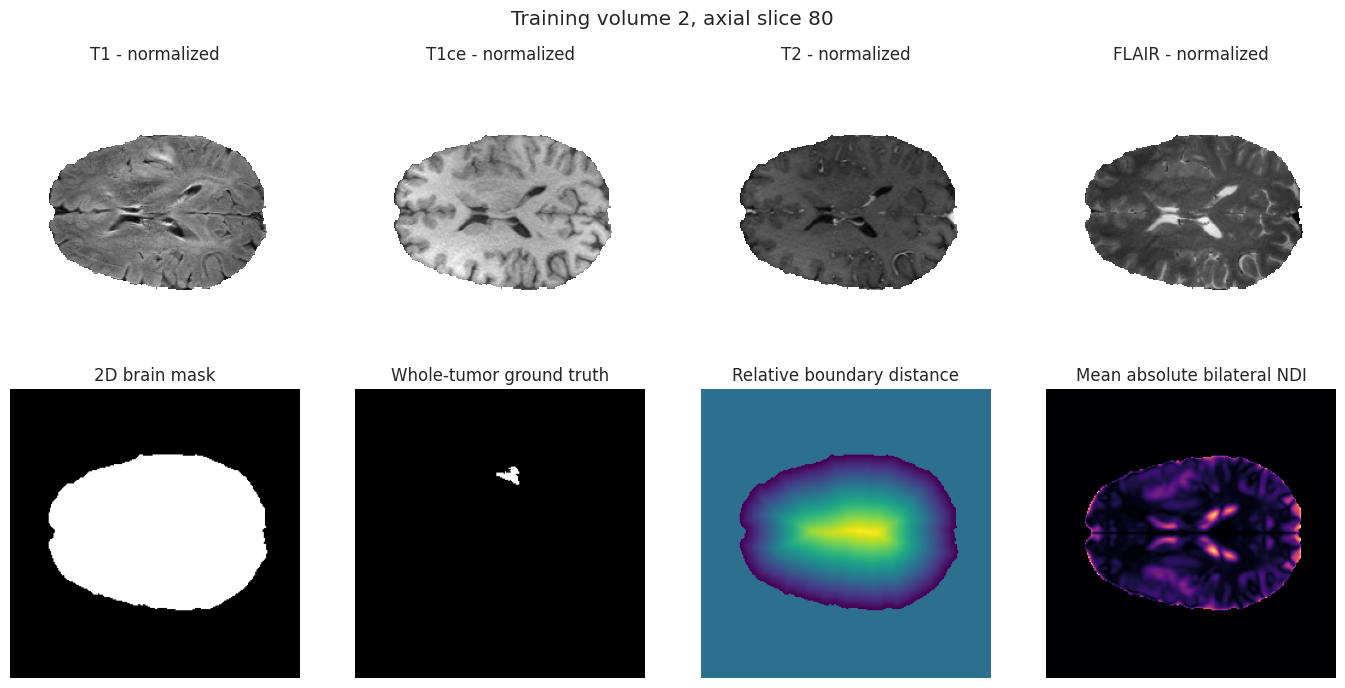

In [9]:
train_manifest = pd.read_csv(SPLITS_DIR / "train_ids.csv")
sample_volume = int(train_manifest.loc[train_manifest["tumor_pixels"] > 0, "volume_id"].iloc[0])
sample = load_preprocessed_slice(sample_volume)

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
for index, name in enumerate(MODALITY_NAMES):
    axes.flat[index].imshow(np.where(sample.brain_mask, sample.image[..., index], np.nan), cmap="gray")
    axes.flat[index].set_title(f"{name} - normalized")
axes.flat[4].imshow(sample.brain_mask, cmap="gray")
axes.flat[4].set_title("2D brain mask")
axes.flat[5].imshow(sample.whole_tumor, cmap="gray")
axes.flat[5].set_title("Whole-tumor ground truth")
axes.flat[6].imshow(sample.distance, cmap="viridis")
axes.flat[6].set_title("Relative boundary distance")
axes.flat[7].imshow(np.mean(np.abs(sample.symmetry), axis=-1), cmap="magma")
axes.flat[7].set_title("Mean absolute bilateral NDI")
for axis in axes.flat:
    axis.axis("off")
fig.suptitle(f"Training volume {sample_volume}, axial slice {SLICE_NUM}")
plt.tight_layout()
plt.show()

## 4. Statistical and image-processing pipelines

### Baseline

`4 MRI modalities -> patient-balanced sampling -> class GMMs -> stable log-sum-exp posterior -> posterior components -> information-theoretic classification -> seed expansion`

### Proposed model

`combined 9D GMM evidence + FLAIR/T2 whole-tumor branch + T1/T1ce core branch -> calibrated posterior -> the same frozen image-processing pipeline`

Sobel edges are retained as a diagnostic, but a candidate no longer requires a perfectly closed edge.

## 5. Model training

Healthy samples are selected randomly and approximately evenly across training patients. Tumor samples are capped per patient and tissue class so large tumors do not dominate. Saved models are reused unless `FORCE_RETRAIN_MODELS=True`.

In [10]:
models = train_or_load_models(splits["train"], force=FORCE_RETRAIN_MODELS)
model_table = pd.DataFrame([
    {"Model": "Raw (4D)", "Features": "T1, T1ce, T2, FLAIR", "Role": "Baseline"},
    {"Model": "Boundary distance (5D)", "Features": "MRI + relative distance", "Role": "Advanced 1"},
    {"Model": "Symmetry (8D)", "Features": "MRI + four bilateral NDI channels", "Role": "Advanced 2"},
    {"Model": "Hierarchical modalities", "Features": "Raw GMM + FLAIR/T2 and T1/T1ce branches", "Role": "Advanced 3"},
    {"Model": "Combined", "Features": "MRI + distance + symmetry + hierarchical branches", "Role": "Final proposed model"},
])
display(model_table)

,Model,Features,Role
0,Raw (4D),"T1, T1ce, T2, FLAIR",Baseline
1,Boundary distance (5D),MRI + relative distance,Advanced 1
2,Symmetry (8D),MRI + four bilateral NDI channels,Advanced 2
3,Hierarchical modalities,Raw GMM + FLAIR/T2 and T1/T1ce branches,Advanced 3
4,Combined,MRI + distance + symmetry + hierarchical branches,Final proposed model


## 6. Baseline validation optimization and parameter freezing

The baseline jointly selects image-processing and probabilistic parameters. After this cell completes, the image-processing parameters are frozen for every advanced model.

In [11]:
if REUSE_SELECTED_PARAMETERS and SELECTED_PARAMETERS_PATH.exists():
    selected = load_selected_parameters()
    frozen_image_params = selected["frozen_image_processing_params"]
    model_probability_params = selected["model_probability_params"]
    optimization_studies = {}
else:
    frozen_image_params, baseline_probability_params, baseline_study, baseline_trial = optimize_baseline(
        models["Raw (4D)"], splits["validation"], n_trials=N_BASELINE_TRIALS
    )
    model_probability_params = {"Raw (4D)": baseline_probability_params}
    optimization_studies = {"Raw (4D)": baseline_study}

print("Frozen image-processing parameters:")
display(pd.DataFrame([frozen_image_params]))
print("Baseline probabilistic parameters:")
display(pd.DataFrame([model_probability_params["Raw (4D)"]]))

[I 2026-08-25 12:44:18,449] A new study created in memory with name: no-name-5731c432-e407-4ddd-9234-abc392bb8c88
Best trial: 0. Best value: 0.708704:   2%|▏         | 1/60 [00:01<01:13,  1.24s/it]

[I 2026-08-25 12:44:19,689] Trial 0 finished with value: 0.7087041696085398 and parameters: {'min_component_size': 12, 'closing_size': 3, 'max_expansion_distance': 40, 'log_odds_offset': 0.0, 'temperature': 1.0, 'candidate_threshold': 0.2, 'component_threshold': 0.5, 'entropy_expansion_threshold': 0.1, 'posterior_expansion_threshold': 0.1}. Best is trial 0 with value: 0.7087041696085398.


Best trial: 0. Best value: 0.708704:   3%|▎         | 2/60 [00:01<00:44,  1.30it/s]

[I 2026-08-25 12:44:20,130] Trial 1 finished with value: 0.1 and parameters: {'min_component_size': 25, 'closing_size': 1, 'max_expansion_distance': 16, 'log_odds_offset': -7.070662205308809, 'temperature': 1.7992642186624028, 'candidate_threshold': 0.3505575058716044, 'component_threshold': 0.7248435466776273, 'entropy_expansion_threshold': 0.029880557261985175, 'posterior_expansion_threshold': 0.43706123642965755}. Best is trial 0 with value: 0.7087041696085398.


Best trial: 2. Best value: 0.710652:   5%|▌         | 3/60 [00:02<00:42,  1.36it/s]

...

Best trial: 41. Best value: 0.745974: 100%|██████████| 60/60 [01:10<00:00,  1.18s/it]

[I 2026-08-25 12:45:28,949] Trial 59 finished with value: 0.6907937253963127 and parameters: {'min_component_size': 31, 'closing_size': 3, 'max_expansion_distance': 50, 'log_odds_offset': -0.1449351226065708, 'temperature': 0.5779581615939735, 'candidate_threshold': 0.36964411750051773, 'component_threshold': 0.30189965606598324, 'entropy_expansion_threshold': 0.09577109720916534, 'posterior_expansion_threshold': 0.13248270242608692}. Best is trial 41 with value: 0.7459743372456067.
Frozen image-processing parameters:


,max_expansion_distance,min_component_size,closing_size
0,51,55,3


Baseline probabilistic parameters:


,log_odds_offset,temperature,candidate_threshold,component_threshold,entropy_expansion_threshold,posterior_expansion_threshold
0,-0.123392,0.940634,0.425514,0.499925,0.07792,0.188363


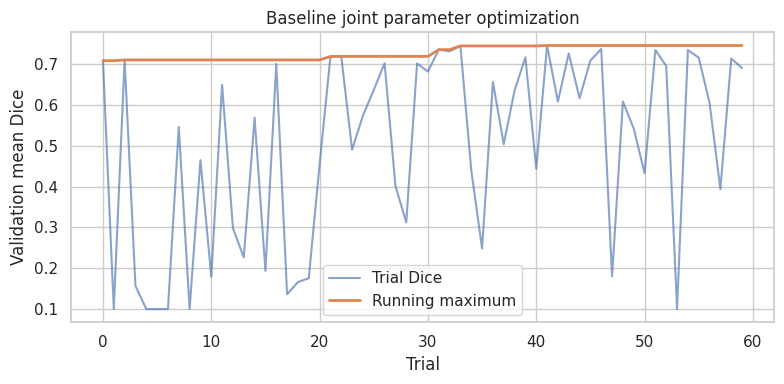

In [12]:
if "Raw (4D)" in optimization_studies:
    history = optimization_studies["Raw (4D)"].trials_dataframe()
    plt.figure(figsize=(8, 4))
    plt.plot(history["number"], history["value"], alpha=0.65, label="Trial Dice")
    plt.plot(history["number"], history["value"].cummax(), linewidth=2, label="Running maximum")
    plt.xlabel("Trial")
    plt.ylabel("Validation mean Dice")
    plt.title("Baseline joint parameter optimization")
    plt.legend()
    plt.tight_layout()
    plt.show()

## 7. Advanced-model validation optimization

Only probabilistic parameters are optimized below. The frozen baseline image-processing parameters are reused without modification.

In [13]:
advanced_names = [
    "Boundary distance (5D)",
    "Symmetry (8D)",
    "Hierarchical modalities",
    "Combined",
]
if not (REUSE_SELECTED_PARAMETERS and SELECTED_PARAMETERS_PATH.exists()):
    for index, model_name in enumerate(advanced_names, start=1):
        probability_params, study, selected_trial = optimize_advanced_model(
            models[model_name],
            splits["validation"],
            frozen_image_params,
            n_trials=N_ADVANCED_TRIALS,
            seed=RANDOM_SEED + index,
        )
        model_probability_params[model_name] = probability_params
        optimization_studies[model_name] = study

validation_results = {}
for model_name, model in models.items():
    result = evaluate_model(
        model,
        splits["validation"],
        frozen_image_params,
        model_probability_params[model_name],
    )
    validation_results[model_name] = result

validation_summary = pd.DataFrame([
    result["summary"] for result in validation_results.values()
])
display(validation_summary.round(4))

if not (REUSE_SELECTED_PARAMETERS and SELECTED_PARAMETERS_PATH.exists()):
    selected = save_selected_parameters(
        frozen_image_params,
        model_probability_params,
        {row["model"]: row for row in validation_summary.to_dict("records")},
    )

[I 2026-08-25 12:45:32,190] A new study created in memory with name: no-name-376e7bec-c7d0-440f-94f4-8abf1ccde651
Best trial: 0. Best value: 0.758675:   2%|▏         | 1/50 [00:00<00:43,  1.14it/s]

[I 2026-08-25 12:45:33,069] Trial 0 finished with value: 0.7586746815615918 and parameters: {'log_odds_offset': 0.0, 'temperature': 1.0, 'candidate_threshold': 0.2, 'component_threshold': 0.5, 'entropy_expansion_threshold': 0.1, 'posterior_expansion_threshold': 0.1}. Best is trial 0 with value: 0.7586746815615918.


Best trial: 0. Best value: 0.758675:   4%|▍         | 2/50 [00:01<00:30,  1.57it/s]

[I 2026-08-25 12:45:33,537] Trial 1 finished with value: 0.1 and parameters: {'log_odds_offset': -6.159126937763537, 'temperature': 1.413599808919222, 'candidate_threshold': 0.11669548209299414, 'component_threshold': 0.4443537719792093, 'entropy_expansion_threshold': 0.17702674678934707, 'posterior_expansion_threshold': 0.389429121107897}. Best is trial 0 with value: 0.7586746815615918.


Best trial: 0. Best value: 0.758675:   6%|▌         | 3/50 [00:01<00:26,  1.78it/s]

...

Best trial: 32. Best value: 0.795733:  98%|█████████▊| 49/50 [00:40<00:00,  1.21it/s]

[I 2026-08-25 12:48:59,043] Trial 48 finished with value: 0.6666464399748885 and parameters: {'log_odds_offset': 0.20930131359007453, 'temperature': 0.970381408463892, 'candidate_threshold': 0.2541074532715639, 'component_threshold': 0.5200474097244911, 'entropy_expansion_threshold': 0.2535793217488351, 'posterior_expansion_threshold': 0.44367226260422243, 'hierarchy_weight': 1.6187036528960612, 'core_weight': 0.8651130385200674}. Best is trial 32 with value: 0.7957333426475075.


Best trial: 32. Best value: 0.795733: 100%|██████████| 50/50 [00:41<00:00,  1.20it/s]


[I 2026-08-25 12:49:00,200] Trial 49 finished with value: 0.47629784758780536 and parameters: {'log_odds_offset': 3.9705979995967833, 'temperature': 1.1829457994291177, 'candidate_threshold': 0.1903533125269779, 'component_threshold': 0.5807379383703221, 'entropy_expansion_threshold': 0.30509282157557727, 'posterior_expansion_threshold': 0.3187177865750071, 'hierarchy_weight': 1.0037604498187973, 'core_weight': 1.114185359690129}. Best is trial 32 with value: 0.7957333426475075.


,model,dice_mean,dice_std,iou_mean,iou_std,tumor_present_dice,precision,recall,missed_tumors,tumor_slices,empty_slice_false_positives,empty_slices
0,Raw (4D),0.7460,0.2668,0.6515,0.2717,0.7844,0.8200,0.8000,1,45,3,5
1,Boundary distance (5D),0.8015,0.1983,0.7057,0.2278,0.7795,0.8850,0.7397,1,45,0,5
2,Symmetry (8D),0.8000,0.2389,0.7147,0.2467,0.8000,0.7991,0.8427,2,45,1,5
3,Hierarchical modalities,0.7584,0.2704,0.6699,0.2767,0.7761,0.8099,0.7956,2,45,2,5
4,Combined,0.7957,0.2450,0.7113,0.2537,0.7953,0.8090,0.8225,2,45,1,5


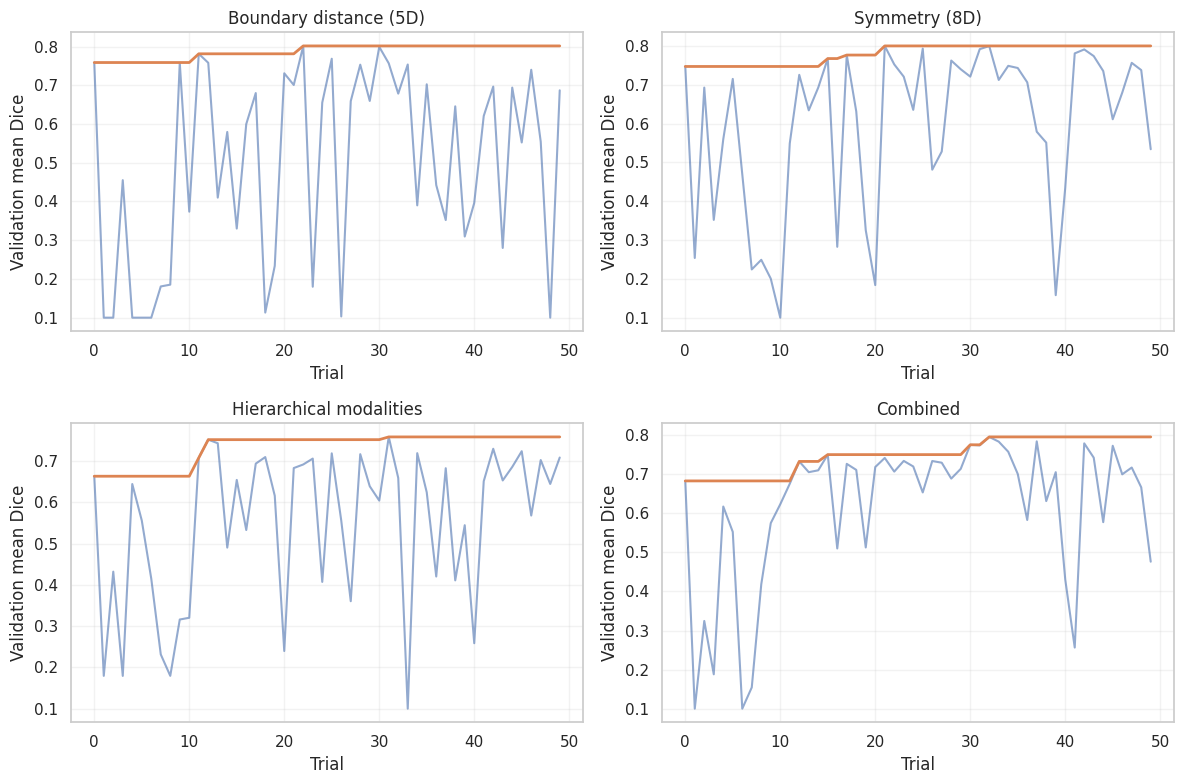

,Model,log_odds_offset,temperature,candidate_threshold,component_threshold,entropy_expansion_threshold,posterior_expansion_threshold,hierarchy_weight,core_weight
0,Raw (4D),-0.1234,0.9406,0.4255,0.4999,0.0779,0.1884,NaN,NaN
1,Boundary distance (5D),-1.2829,1.7022,0.4534,0.5601,0.2650,0.2218,NaN,NaN
2,Symmetry (8D),-0.3384,1.0033,0.1655,0.5322,0.1029,0.1227,NaN,NaN
3,Hierarchical modalities,-0.9263,1.8049,0.2608,0.5961,0.1947,0.2545,0.9408,2.5608
4,Combined,-1.3075,1.1152,0.2080,0.7179,0.3500,0.3427,1.5012,0.5272


In [14]:
if optimization_studies:
    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    for axis, model_name in zip(axes.flat, advanced_names):
        history = optimization_studies[model_name].trials_dataframe()
        axis.plot(history["number"], history["value"], alpha=0.6)
        axis.plot(history["number"], history["value"].cummax(), linewidth=2)
        axis.set_title(model_name)
        axis.set_xlabel("Trial")
        axis.set_ylabel("Validation mean Dice")
        axis.grid(alpha=0.25)
    plt.tight_layout()
    plt.show()

parameter_rows = []
for model_name, parameters in model_probability_params.items():
    parameter_rows.append({"Model": model_name, **parameters})
display(pd.DataFrame(parameter_rows).round(4))

## 8. Validation posterior inspection

This inspection compares the probability evidence before the test set is evaluated.

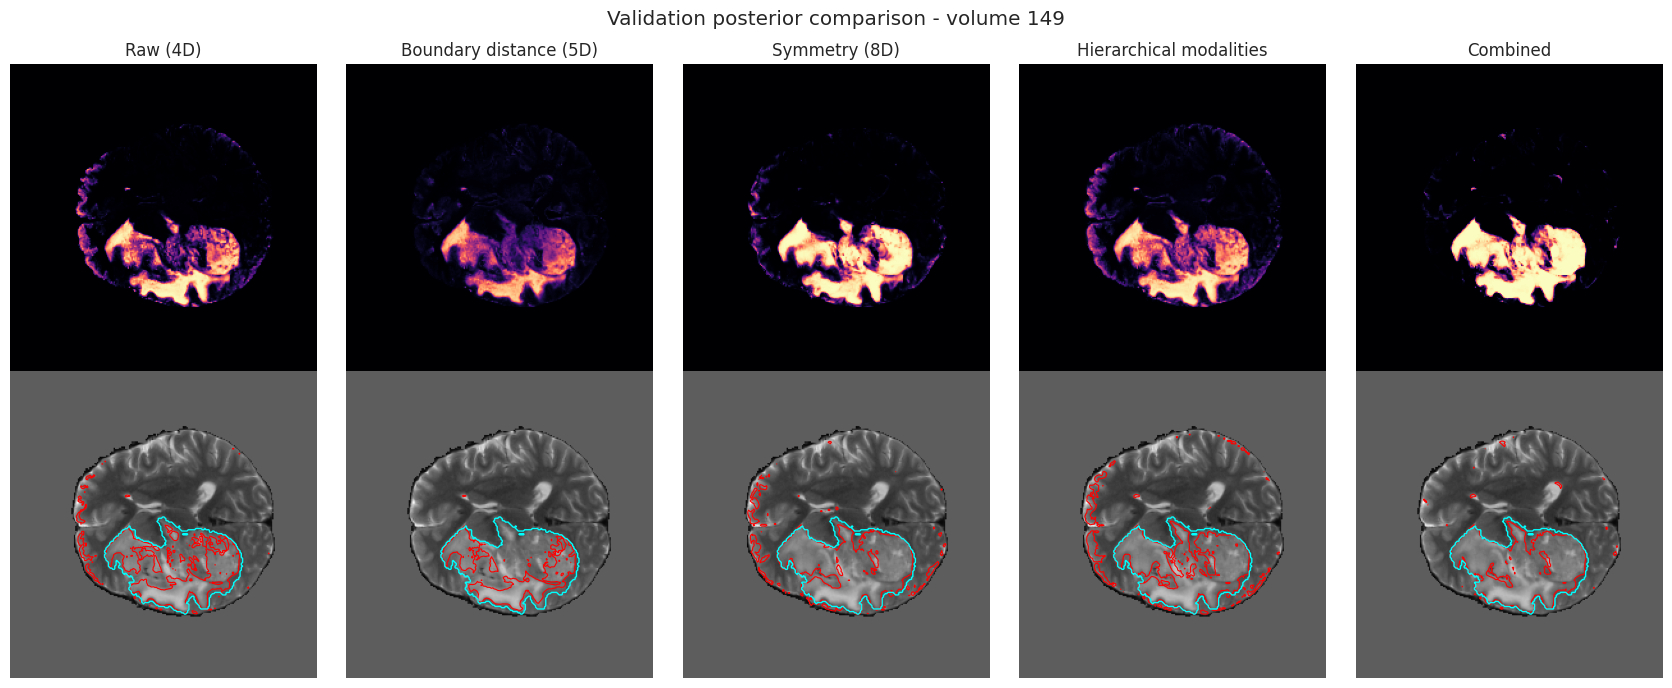

In [15]:
inspection_volume = int(pd.read_csv(SPLITS_DIR / "validation_ids.csv").sort_values("tumor_pixels", ascending=False)["volume_id"].iloc[0])
inspection_data = load_preprocessed_slice(inspection_volume)
fig, axes = plt.subplots(2, 5, figsize=(17, 7))
for column, model_name in enumerate(MODEL_NAMES):
    evidence = models[model_name].prepare(inspection_data)
    posterior = models[model_name].posteriors_from_evidence(evidence, model_probability_params[model_name])
    tumor_probability = posterior[..., 1:].sum(axis=-1)
    axes[0, column].imshow(tumor_probability, cmap="magma", vmin=0, vmax=1)
    axes[0, column].set_title(model_name)
    axes[1, column].imshow(inspection_data.image[..., 3], cmap="gray")
    axes[1, column].contour(tumor_probability, levels=[model_probability_params[model_name]["candidate_threshold"]], colors="red", linewidths=0.8)
    axes[1, column].contour(inspection_data.whole_tumor, levels=[0.5], colors="cyan", linewidths=1)
    axes[0, column].axis("off")
    axes[1, column].axis("off")
axes[0, 0].set_ylabel("Tumor posterior")
axes[1, 0].set_ylabel("FLAIR: red candidate, cyan GT")
fig.suptitle(f"Validation posterior comparison - volume {inspection_volume}")
plt.tight_layout()
plt.show()

## 9. Final frozen test evaluation

This is the first and only test-set inference step. All model and image-processing parameters are already frozen.

In [16]:
TEST_RESULTS = {}
for model_name, model in models.items():
    result = evaluate_model(
        model,
        splits["test"],
        frozen_image_params,
        model_probability_params[model_name],
        return_details=True,
    )
    TEST_RESULTS[model_name] = result
    save_evaluation(result, TEST_OUTPUT_DIR, model_name.lower().replace(" ", "_").replace("(", "").replace(")", ""))

test_summary = pd.DataFrame([result["summary"] for result in TEST_RESULTS.values()])
test_summary["Missed tumors"] = test_summary["missed_tumors"].astype(str) + "/" + test_summary["tumor_slices"].astype(str)
test_summary["Empty-slice FP"] = test_summary["empty_slice_false_positives"].astype(str) + "/" + test_summary["empty_slices"].astype(str)
display(test_summary[[
    "model", "dice_mean", "dice_std", "tumor_present_dice", "precision", "recall",
    "iou_mean", "iou_std", "Missed tumors", "Empty-slice FP",
]].round(4))

,model,dice_mean,dice_std,tumor_present_dice,precision,recall,iou_mean,iou_std,Missed tumors,Empty-slice FP
0,Raw (4D),0.6742,0.3350,0.7342,0.7673,0.7990,0.5893,0.3236,3/62,6/7
1,Boundary distance (5D),0.7226,0.3128,0.7235,0.8039,0.6905,0.6396,0.3067,6/62,2/7
2,Symmetry (8D),0.7396,0.3244,0.7264,0.7320,0.7610,0.6679,0.3192,7/62,1/7
3,Hierarchical modalities,0.6823,0.3671,0.6948,0.7110,0.7132,0.6145,0.3510,11/62,3/7
4,Combined,0.7136,0.3482,0.7297,0.7474,0.7381,0.6442,0.3340,9/62,3/7


### Required baseline-versus-proposed table

The course requires the mean and standard deviation of Dice and IoU for the baseline and final proposed model.

In [17]:
required_table = test_summary[test_summary["model"].isin(["Raw (4D)", "Combined"])][[
    "model", "dice_mean", "dice_std", "iou_mean", "iou_std"
]].rename(columns={
    "model": "Model", "dice_mean": "Dice mean", "dice_std": "Dice std",
    "iou_mean": "IoU mean", "iou_std": "IoU std",
})
display(required_table.round(4))

,Model,Dice mean,Dice std,IoU mean,IoU std
0,Raw (4D),0.6742,0.3350,0.5893,0.3236
4,Combined,0.7136,0.3482,0.6442,0.3340


### Required Dice and IoU boxplots

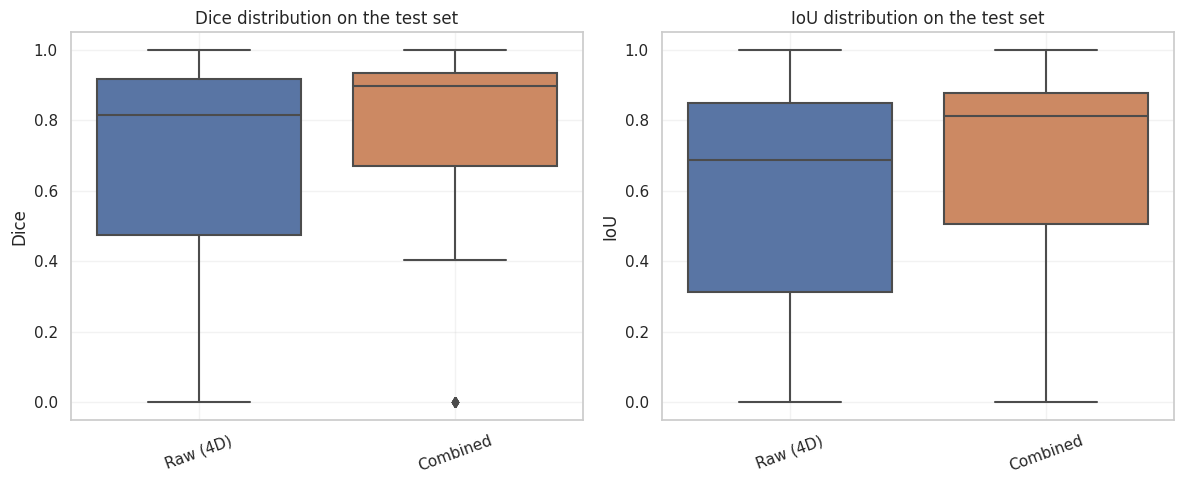

In [18]:
required_frames = [
    TEST_RESULTS["Raw (4D)"]["per_volume"],
    TEST_RESULTS["Combined"]["per_volume"],
]
plot_metric_boxplots(required_frames, FIGURES_DIR / "required_dice_iou_boxplots.png")
plt.show()

### Five-model ablation boxplots

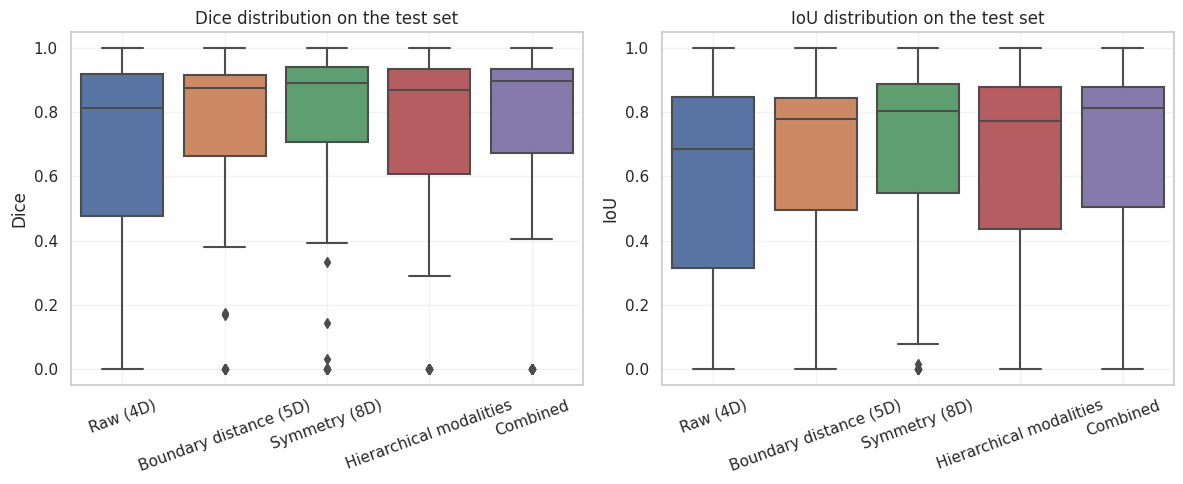

In [19]:
plot_metric_boxplots(
    [TEST_RESULTS[name]["per_volume"] for name in MODEL_NAMES],
    FIGURES_DIR / "all_models_dice_iou_boxplots.png",
)
plt.show()

### Required patient-level scatterplots

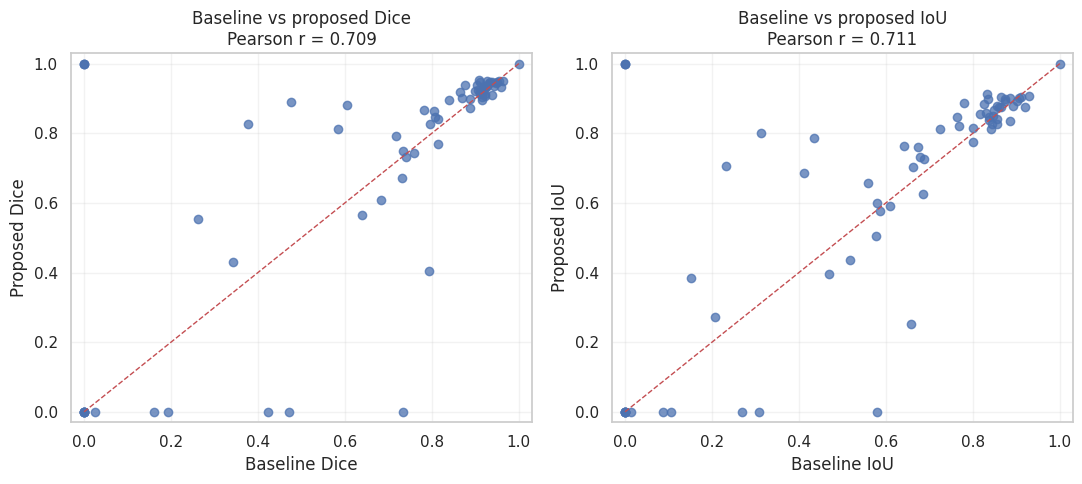

In [20]:
plot_required_scatterplots(
    TEST_RESULTS["Raw (4D)"]["per_volume"],
    TEST_RESULTS["Combined"]["per_volume"],
    FIGURES_DIR / "required_baseline_proposed_scatterplots.png",
)
plt.show()

### Additional paired baseline-versus-advanced scatterplots

These plots preserve the complete paired-model inspection from the original project notebook.

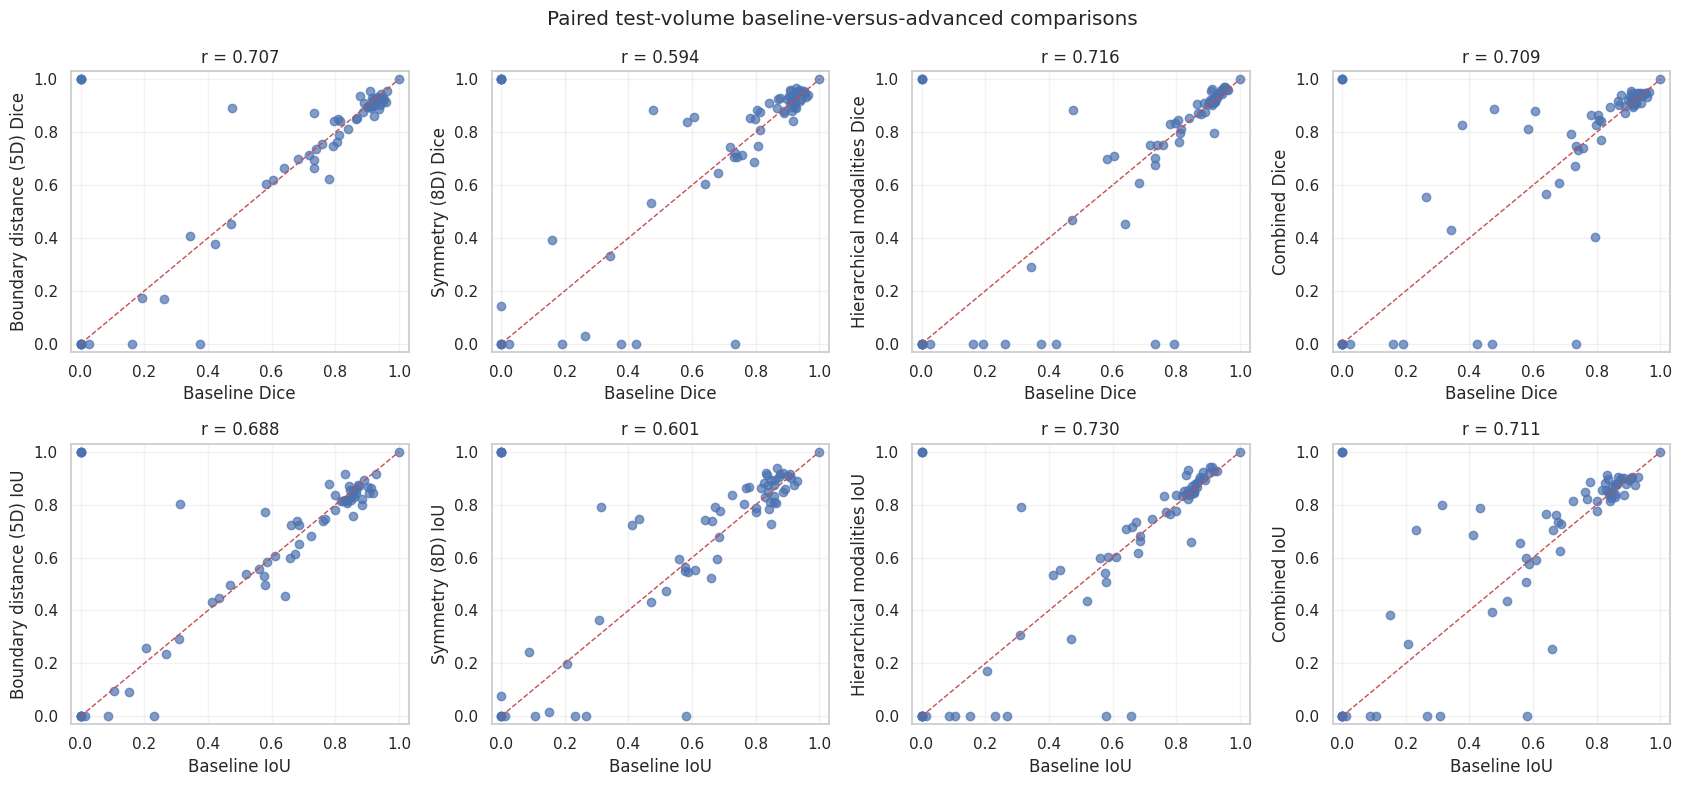

In [21]:
advanced_names_for_plot = [name for name in MODEL_NAMES if name != "Raw (4D)"]
fig, axes = plt.subplots(2, len(advanced_names_for_plot), figsize=(17, 8))
baseline_frame = TEST_RESULTS["Raw (4D)"]["per_volume"]
for column, model_name in enumerate(advanced_names_for_plot):
    advanced_frame = TEST_RESULTS[model_name]["per_volume"]
    merged = baseline_frame.merge(advanced_frame, on="volume_id", suffixes=("_baseline", "_advanced"))
    for row, (metric, label) in enumerate((("dice", "Dice"), ("iou", "IoU"))):
        x = merged[f"{metric}_baseline"]
        y = merged[f"{metric}_advanced"]
        correlation = np.corrcoef(x, y)[0, 1]
        axes[row, column].scatter(x, y, alpha=0.7)
        axes[row, column].plot([0, 1], [0, 1], "r--", linewidth=1)
        axes[row, column].set(
            xlim=(-0.03, 1.03), ylim=(-0.03, 1.03),
            xlabel=f"Baseline {label}", ylabel=f"{model_name} {label}",
            title=f"r = {correlation:.3f}",
        )
        axes[row, column].grid(alpha=0.25)
fig.suptitle("Paired test-volume baseline-versus-advanced comparisons")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "all_paired_model_scatterplots.png", dpi=300, bbox_inches="tight")
plt.show()

## 10. Failure analysis and additional diagnostics

In [22]:
per_volume_comparison = pd.DataFrame({"volume_id": splits["test"]})
for model_name in MODEL_NAMES:
    frame = TEST_RESULTS[model_name]["per_volume"]
    per_volume_comparison = per_volume_comparison.merge(
        frame[["volume_id", "dice", "iou", "precision", "recall", "ground_truth_size", "prediction_size"]].rename(columns={
            column: f"{model_name} {column}" for column in frame.columns if column != "volume_id"
        }),
        on="volume_id",
    )
display(per_volume_comparison.round(4))
per_volume_comparison.to_csv(TEST_OUTPUT_DIR / "all_models_per_volume.csv", index=False)

,volume_id,Raw (4D) dice,Raw (4D) iou,Raw (4D) precision,Raw (4D) recall,Raw (4D) ground_truth_size,Raw (4D) prediction_size,Boundary distance (5D) dice,Boundary distance (5D) iou,Boundary distance (5D) precision,...,Hierarchical modalities precision,Hierarchical modalities recall,Hierarchical modalities ground_truth_size,Hierarchical modalities prediction_size,Combined dice,Combined iou,Combined precision,Combined recall,Combined ground_truth_size,Combined prediction_size
0,1,0.8994,0.8172,0.9934,0.8217,4217,3488,0.8971,0.8133,0.9957,...,0.9645,0.8572,4217,3748,0.9222,0.8556,0.9638,0.8840,4217,3868
1,3,0.6827,0.5182,0.5218,0.9867,678,1282,0.6985,0.5366,0.5679,...,0.4392,0.9912,678,1530,0.6074,0.4362,0.4505,0.9322,678,1403
2,4,0.9480,0.9012,0.9851,0.9136,2536,2352,0.9279,0.8655,0.9841,...,0.9724,0.9456,2536,2466,0.9430,0.8922,0.9335,0.9527,2536,2588
3,6,0.9065,0.8290,0.9717,0.8495,2591,2265,0.8994,0.8171,0.9893,...,0.9623,0.8672,2591,2335,0.9228,0.8567,0.9855,0.8676,2591,2281
4,7,0.6395,0.4700,0.4700,1.0000,235,500,0.6629,0.4957,0.4979,...,0.2919,1.0000,235,805,0.5659,0.3946,0.3953,0.9957,235,592
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
64,324,0.9628,0.9284,0.9739,0.9520,1293,1264,0.9565,0.9167,0.9876,...,0.9441,0.9791,1293,1341,0.9506,0.9058,0.9149,0.9892,1293,1398
65,334,0.9116,0.8376,0.9596,0.8682,3088,2794,0.8921,0.8052,0.9929,...,0.9585,0.8899,3088,2867,0.9172,0.8470,0.9574,0.8802,3088,2839
66,347,0.8765,0.7801,0.8302,0.9283,1143,1278,0.9356,0.8790,0.9431,...,0.8037,0.9423,1143,1340,0.9398,0.8864,0.9246,0.9554,1143,1181
67,348,0.9083,0.8320,0.8948,0.9222,1697,1749,0.9568,0.9172,0.9881,...,0.9831,0.9263,1697,1599,0.9540,0.9121,0.9801,0.9293,1697,1609


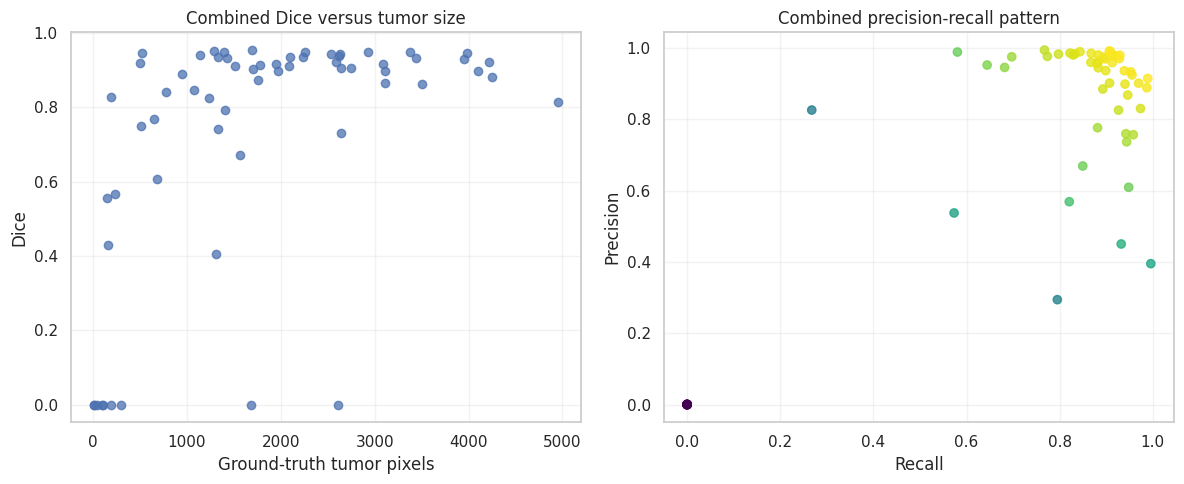

In [23]:
combined_frame = TEST_RESULTS["Combined"]["per_volume"]
tumor_rows = combined_frame[combined_frame["tumor_present"]]
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].scatter(tumor_rows["ground_truth_size"], tumor_rows["dice"], alpha=0.75)
axes[0].set(xlabel="Ground-truth tumor pixels", ylabel="Dice", title="Combined Dice versus tumor size")
axes[1].scatter(tumor_rows["recall"], tumor_rows["precision"], c=tumor_rows["dice"], cmap="viridis", alpha=0.8)
axes[1].set(xlabel="Recall", ylabel="Precision", title="Combined precision-recall pattern")
for axis in axes:
    axis.grid(alpha=0.25)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "combined_failure_analysis.png", dpi=300, bbox_inches="tight")
plt.show()

In [24]:
error_case_table = pd.DataFrame([
    {
        "Model": name,
        "Missed tumor volumes": TEST_RESULTS[name]["per_volume"].loc[
            TEST_RESULTS[name]["per_volume"]["missed_tumor"], "volume_id"
        ].astype(int).tolist(),
        "Empty-slice false-positive volumes": TEST_RESULTS[name]["per_volume"].loc[
            TEST_RESULTS[name]["per_volume"]["empty_slice_false_positive"], "volume_id"
        ].astype(int).tolist(),
    }
    for name in MODEL_NAMES
])
display(error_case_table)

,Model,Missed tumor volumes,Empty-slice false-positive volumes
0,Raw (4D),"[46, 102, 206]","[94, 108, 158, 209, 229, 288]"
1,Boundary distance (5D),"[46, 89, 102, 111, 206, 283]","[94, 229]"
2,Symmetry (8D),"[19, 46, 89, 102, 157, 283, 297]",[108]
3,Hierarchical modalities,"[19, 46, 89, 102, 111, 157, 188, 206, 227, 283...","[94, 108, 158]"
4,Combined,"[19, 46, 102, 111, 157, 206, 283, 285, 297]","[94, 108, 158]"


### Tumors missed by at least one model

The following paginated error maps preserve the original multi-model missed-tumor inspection. Green denotes true positive, red false positive and blue false negative.

,Volume,GT pixels,Raw (4D) Dice,Boundary distance (5D) Dice,Symmetry (8D) Dice,Hierarchical modalities Dice,Combined Dice
0,19,107,0.192,0.173,0.000,0.000,0.000
1,46,13,0.000,0.000,0.000,0.000,0.000
2,89,196,0.376,0.000,0.000,0.000,0.828
3,102,40,0.000,0.000,0.000,0.000,0.000
4,111,97,0.161,0.000,0.392,0.000,0.000
5,157,189,0.423,0.379,0.000,0.000,0.000
6,188,1315,0.794,0.749,0.687,0.000,0.404
7,206,294,0.000,0.000,0.144,0.000,0.000
8,227,150,0.263,0.168,0.030,0.000,0.555
9,283,14,0.026,0.000,0.000,0.000,0.000


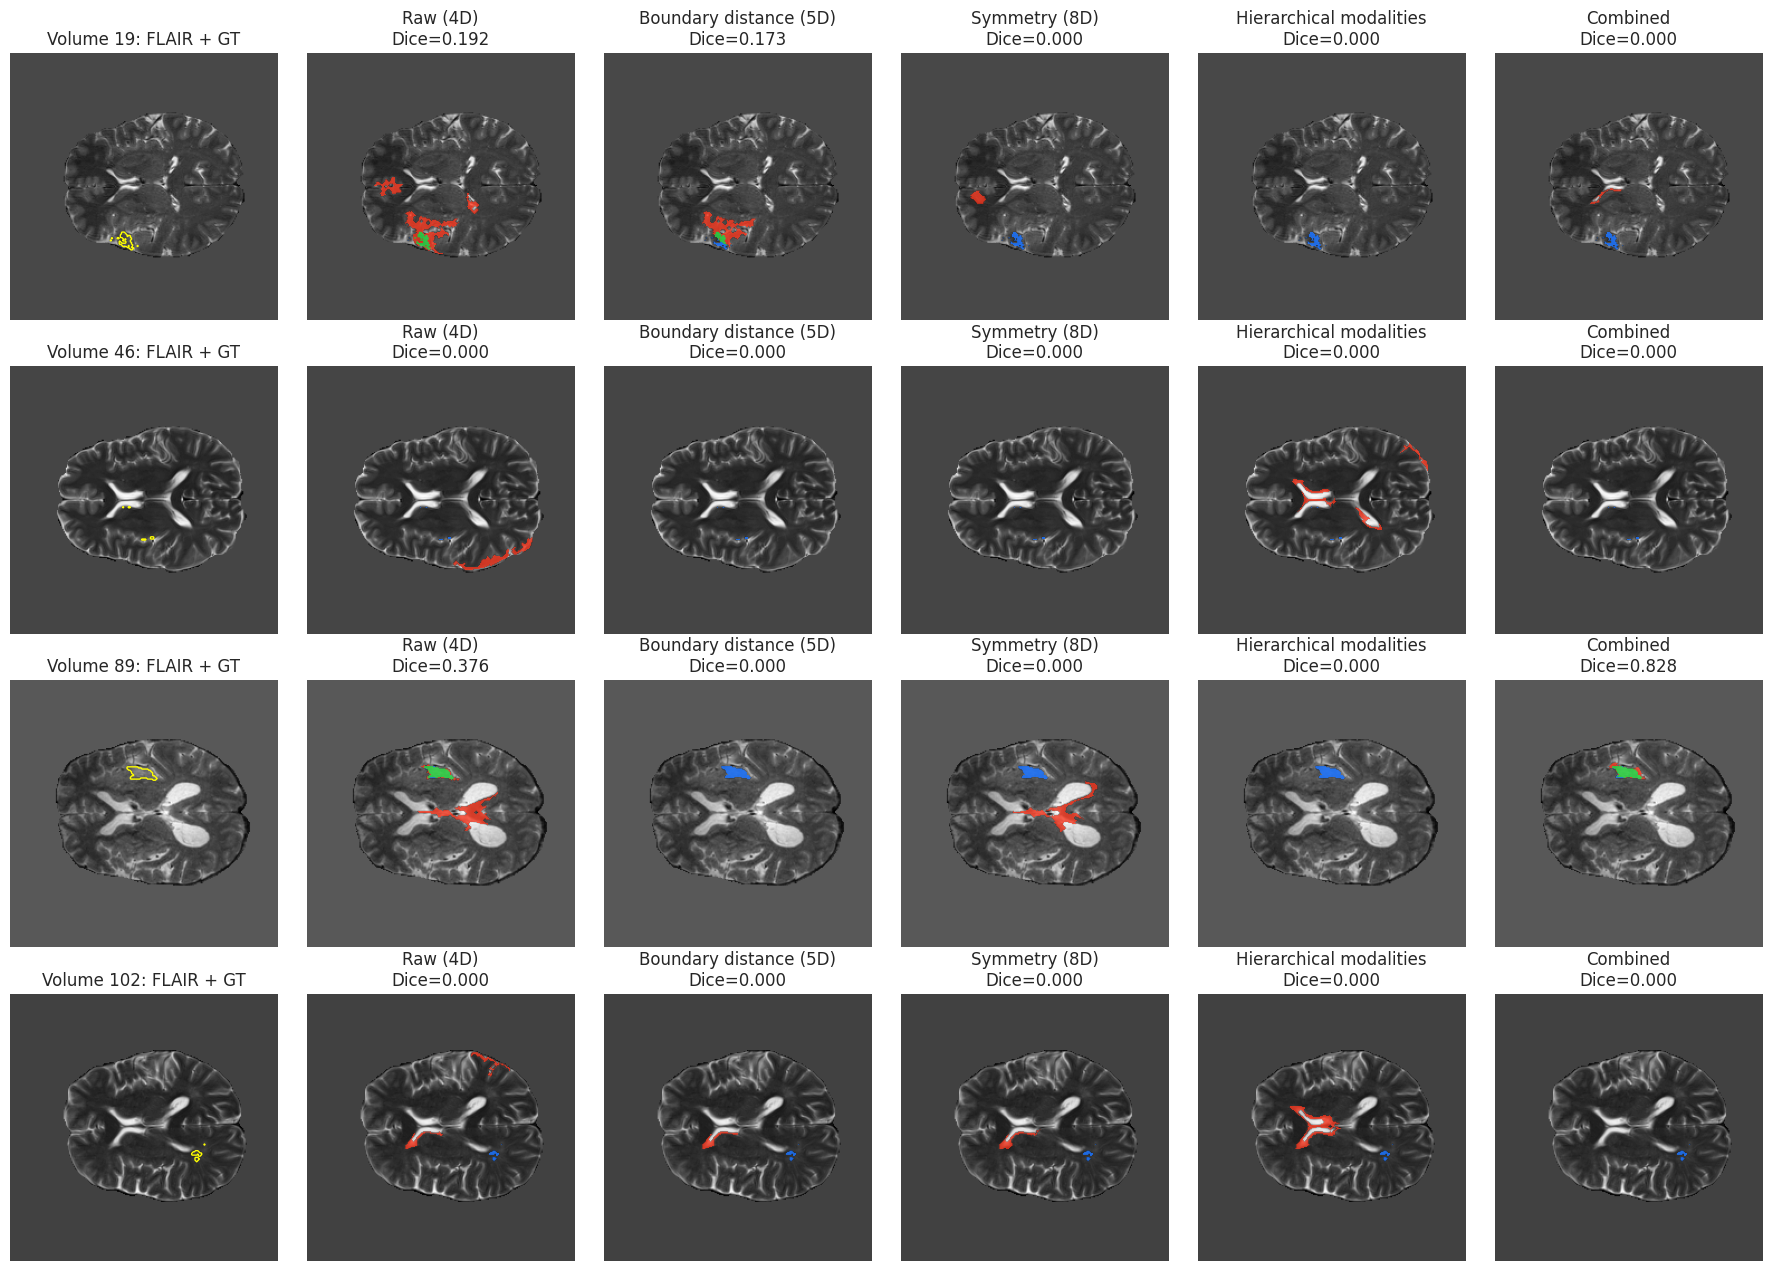

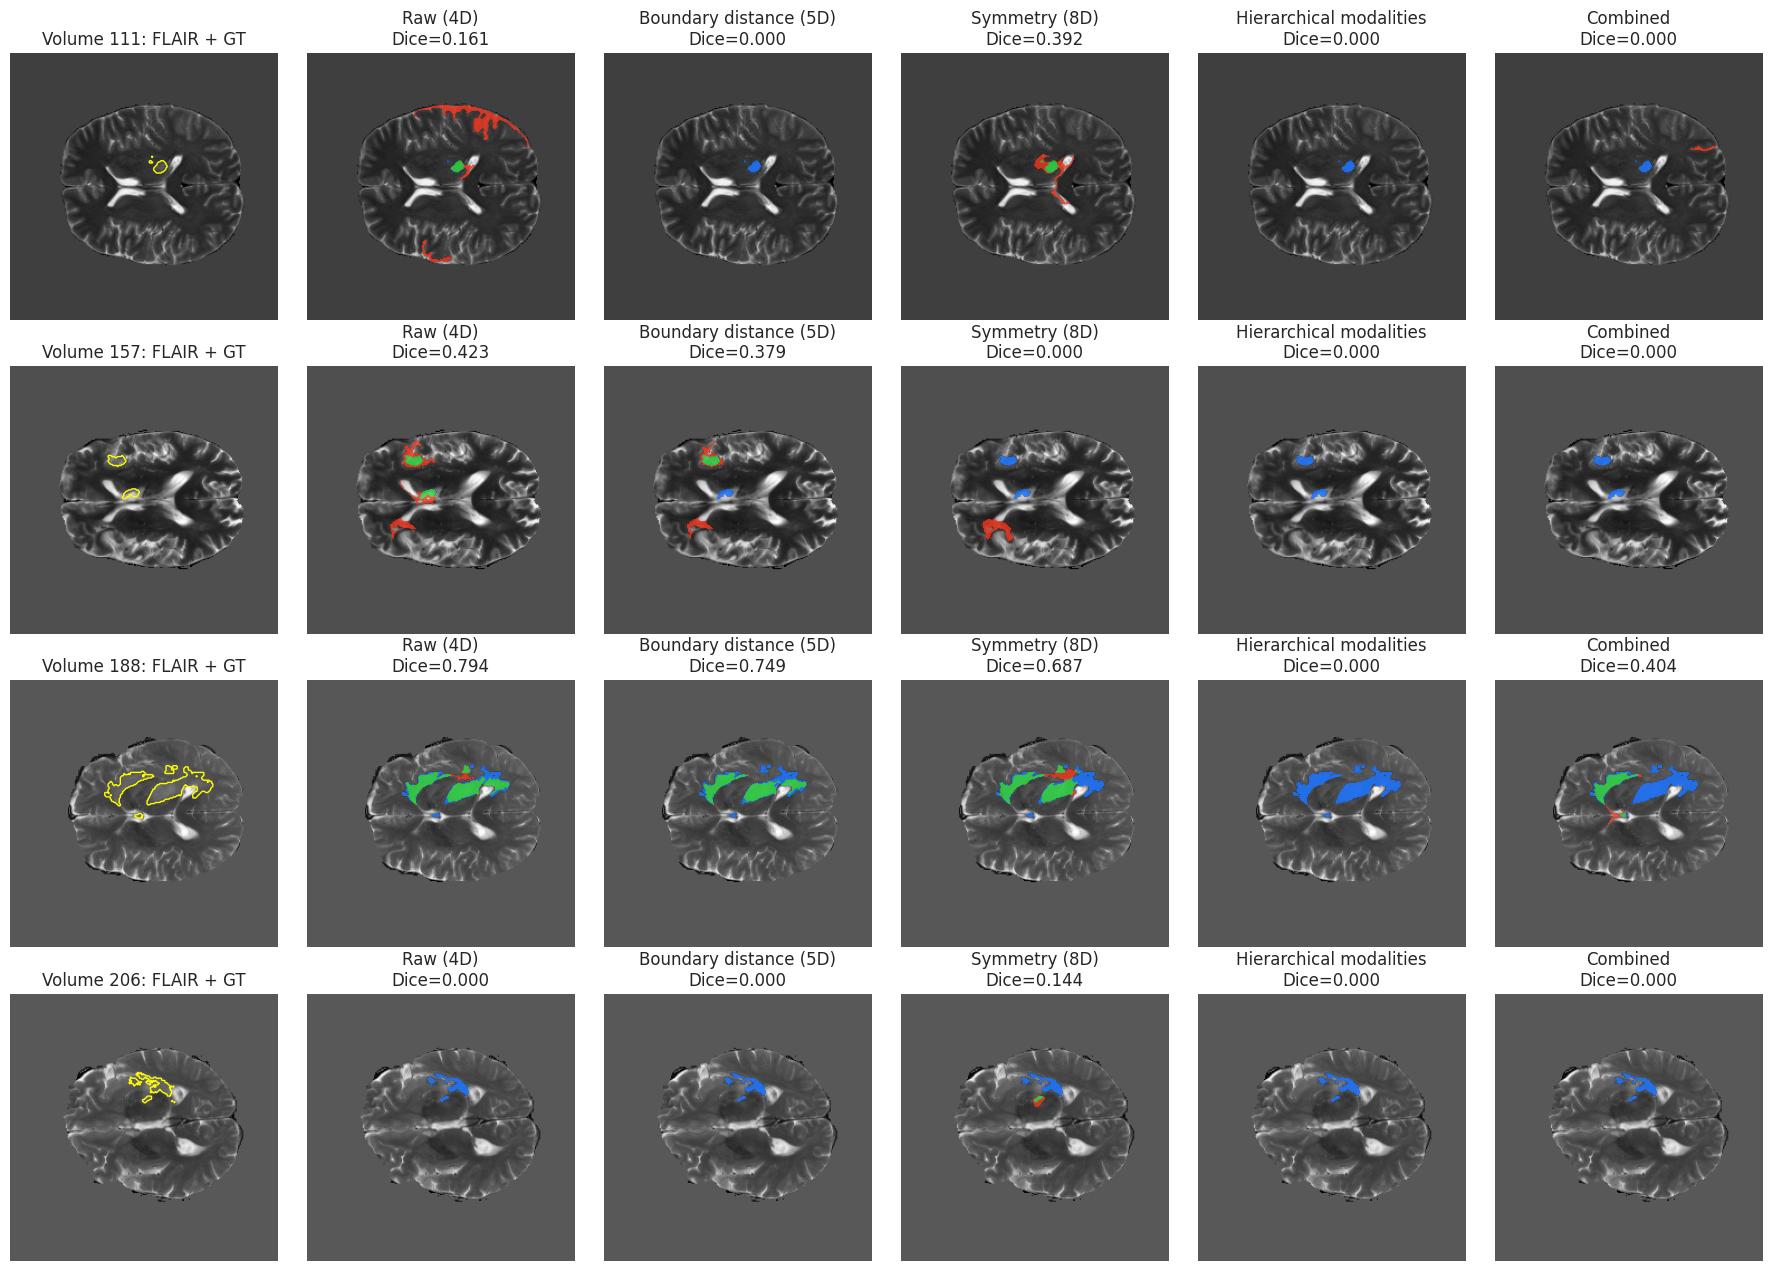

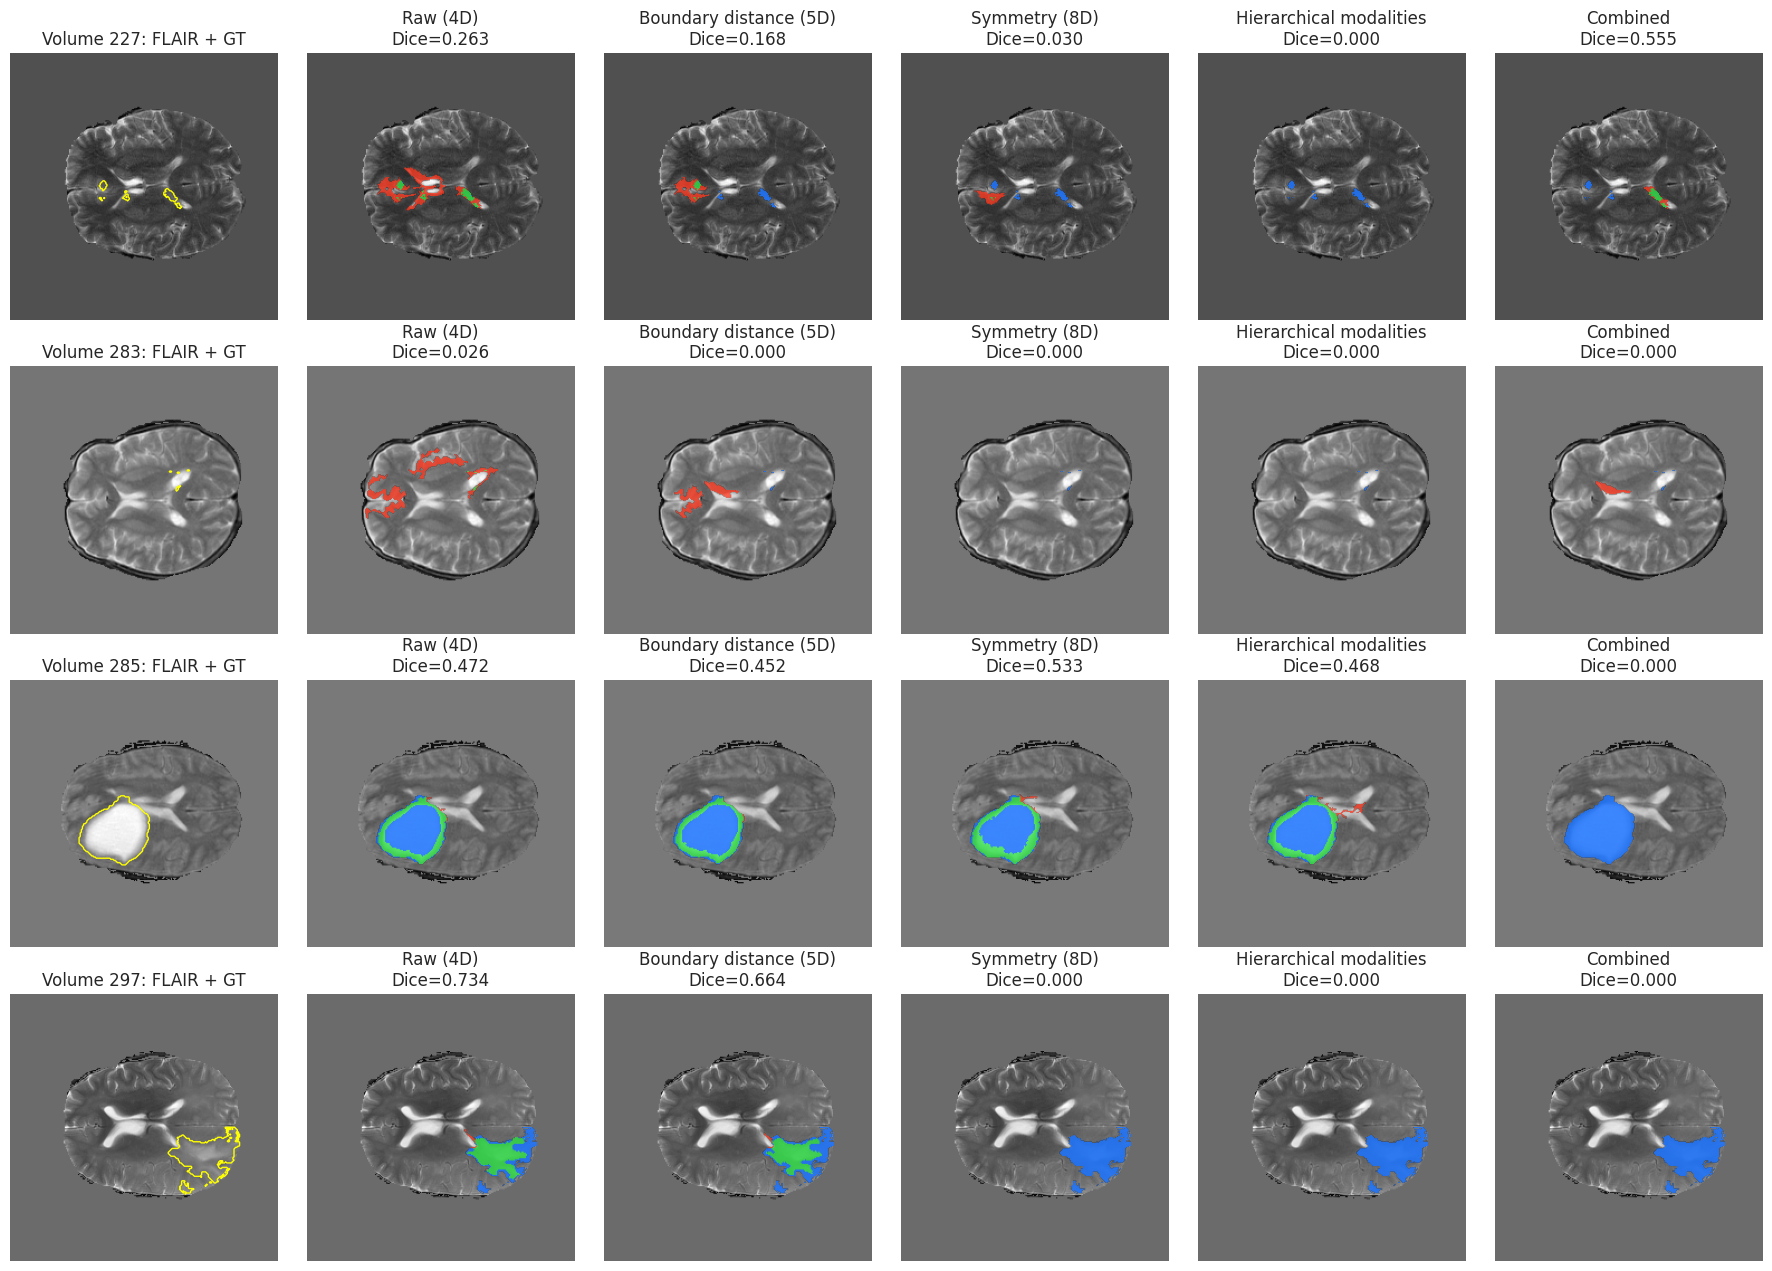

In [25]:
def error_overlay(ground_truth, prediction):
    overlay = np.zeros((*ground_truth.shape, 4), dtype=float)
    overlay[ground_truth & prediction] = (0.15, 0.90, 0.25, 0.75)
    overlay[~ground_truth & prediction] = (1.00, 0.20, 0.10, 0.75)
    overlay[ground_truth & ~prediction] = (0.10, 0.45, 1.00, 0.85)
    return overlay

all_missed_volumes = sorted(set().union(*[
    set(TEST_RESULTS[name]["per_volume"].loc[
        TEST_RESULTS[name]["per_volume"]["missed_tumor"], "volume_id"
    ].astype(int))
    for name in MODEL_NAMES
]))
missed_rows = []
for volume_id in all_missed_volumes:
    row = {"Volume": volume_id, "GT pixels": TEST_RESULTS["Raw (4D)"]["details"][volume_id]["ground_truth_size"]}
    for model_name in MODEL_NAMES:
        row[f"{model_name} Dice"] = TEST_RESULTS[model_name]["details"][volume_id]["dice"]
    missed_rows.append(row)
display(pd.DataFrame(missed_rows).round(3))

rows_per_page = 4
for page, start in enumerate(range(0, len(all_missed_volumes), rows_per_page), start=1):
    page_volumes = all_missed_volumes[start:start + rows_per_page]
    fig, axes = plt.subplots(len(page_volumes), 1 + len(MODEL_NAMES), figsize=(18, 3.2 * len(page_volumes)), squeeze=False)
    for row_index, volume_id in enumerate(page_volumes):
        reference = TEST_RESULTS["Raw (4D)"]["details"][volume_id]
        flair = reference["data"].image[..., 3]
        ground_truth = reference["data"].whole_tumor
        axes[row_index, 0].imshow(flair, cmap="gray")
        if ground_truth.any():
            axes[row_index, 0].contour(ground_truth, levels=[0.5], colors="yellow", linewidths=1)
        axes[row_index, 0].set_title(f"Volume {volume_id}: FLAIR + GT")
        for column, model_name in enumerate(MODEL_NAMES, start=1):
            details = TEST_RESULTS[model_name]["details"][volume_id]
            axes[row_index, column].imshow(flair, cmap="gray")
            axes[row_index, column].imshow(error_overlay(ground_truth, details["prediction"]))
            axes[row_index, column].set_title(f"{model_name}\nDice={details['dice']:.3f}")
        for axis in axes[row_index]:
            axis.axis("off")
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / f"missed_tumor_error_maps_{page}.png", dpi=250, bbox_inches="tight")
    plt.show()

### Complete pipeline trace

This trace verifies whether a poor case fails at the posterior, component-classification, or expansion stage.

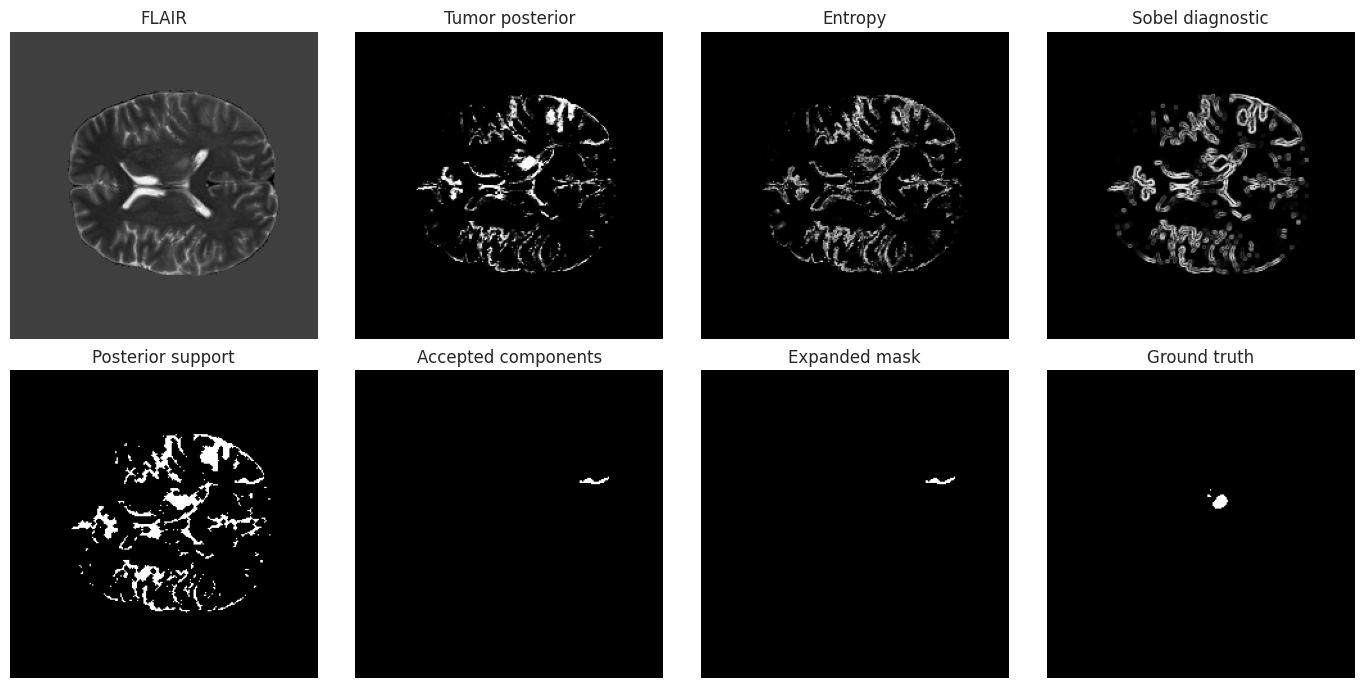

,component,area,weighted_tumor_probability,accepted
0,0,356,0.4648,False
1,1,391,0.7098,False
2,2,60,0.7295,True
3,3,444,0.6468,False
4,4,241,0.5998,False
5,5,60,0.6254,False
6,6,193,0.3779,False
7,7,156,0.6339,False
8,8,294,0.4327,False
9,9,95,0.5625,False


In [26]:
worst_tumor_volume = int(tumor_rows.sort_values("dice").iloc[0]["volume_id"])
worst_details = TEST_RESULTS["Combined"]["details"][worst_tumor_volume]
plot_pipeline_diagnostic(
    worst_details,
    FIGURES_DIR / f"pipeline_trace_volume_{worst_tumor_volume}.png",
)
plt.show()
display(pd.DataFrame(worst_details["component_table"]).round(4))

### Required four qualitative examples

,Required category,Volume
0,Both performed well,324
1,Both performed poorly,206
2,Baseline performed better,297
3,Proposed model performed better,89


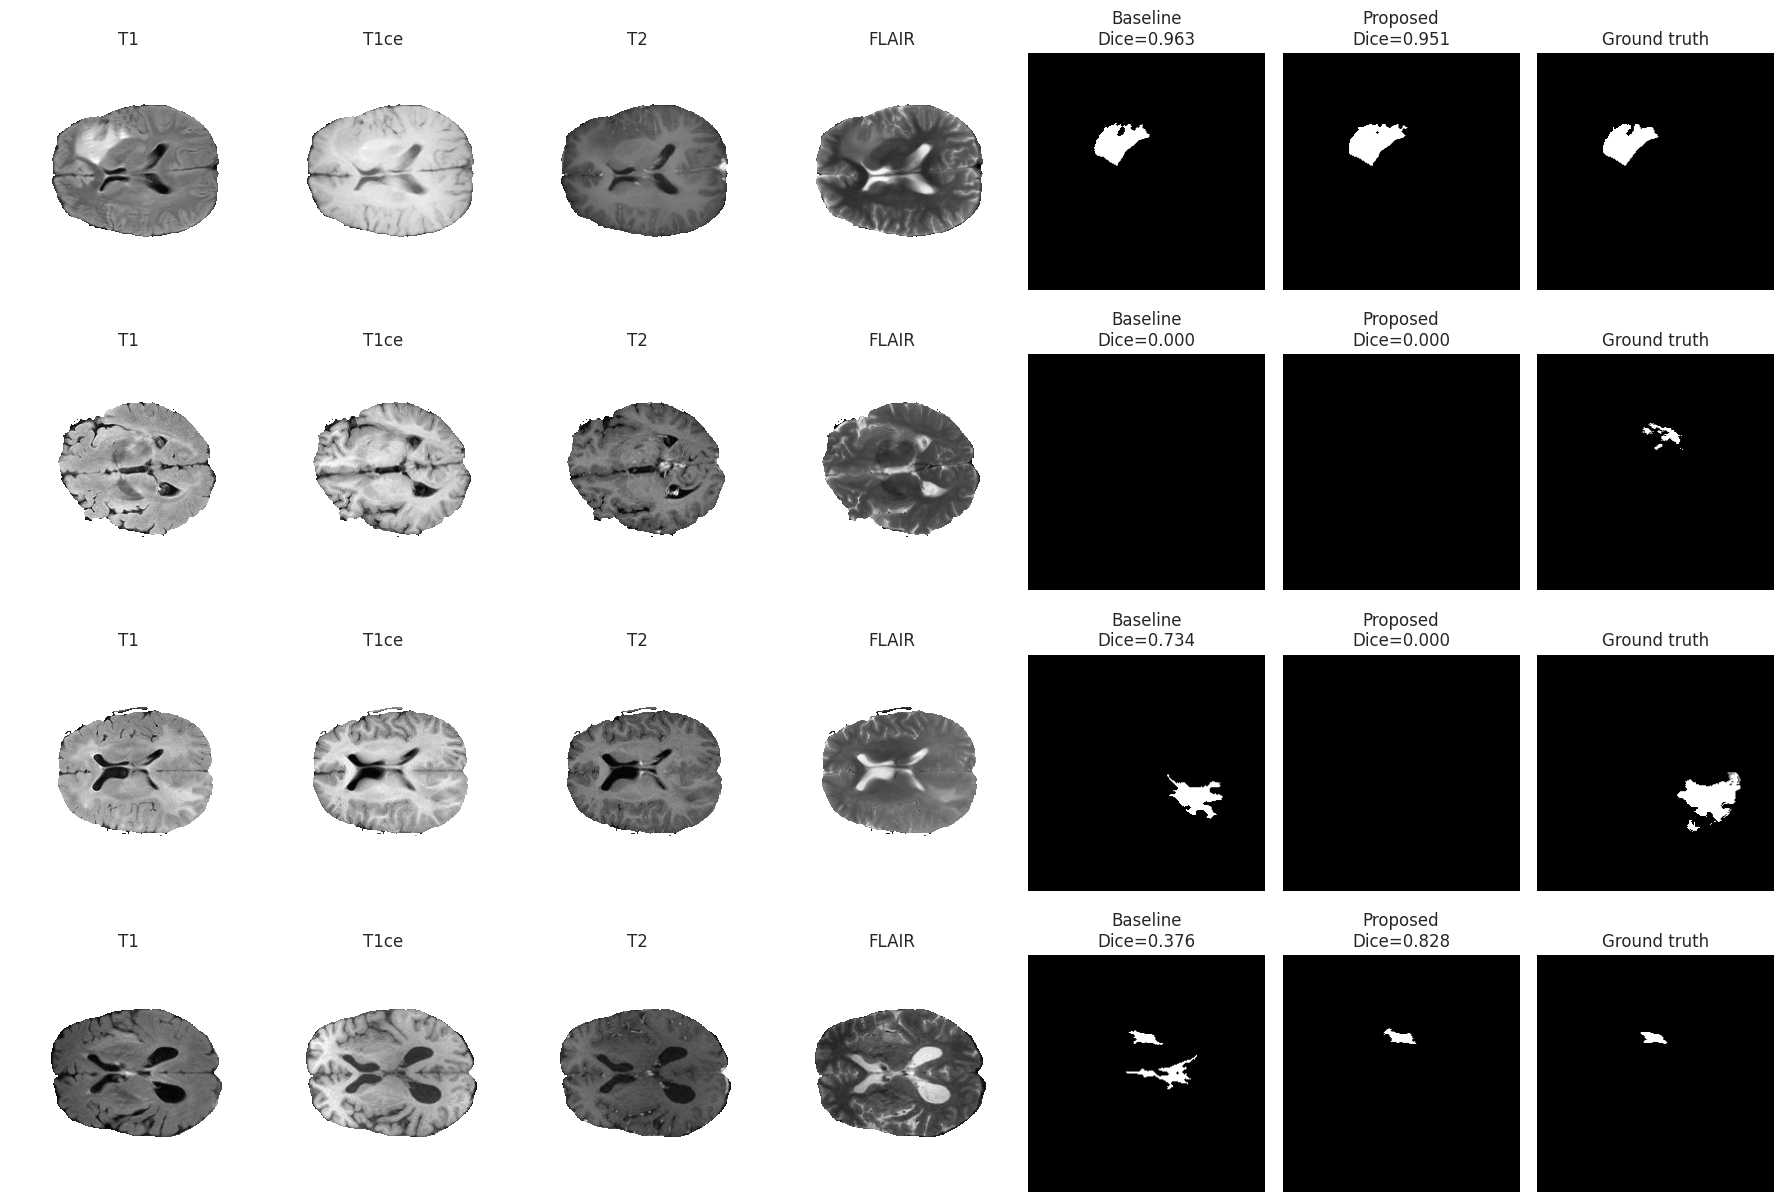

In [27]:
selected_examples = choose_qualitative_examples(
    TEST_RESULTS["Raw (4D)"]["per_volume"],
    TEST_RESULTS["Combined"]["per_volume"],
)
display(pd.DataFrame(selected_examples.items(), columns=["Required category", "Volume"]))
plot_qualitative_examples(
    selected_examples,
    TEST_RESULTS["Raw (4D)"]["details"],
    TEST_RESULTS["Combined"]["details"],
    FIGURES_DIR / "required_qualitative_examples.png",
)
plt.show()

In [28]:
qualitative_explanations = []
for category, volume_id in selected_examples.items():
    if volume_id is None:
        qualitative_explanations.append({
            "Category": category,
            "Volume": "None",
            "Explanation": "No test case satisfied this requested relationship.",
        })
        continue
    baseline = TEST_RESULTS["Raw (4D)"]["details"][volume_id]
    proposed = TEST_RESULTS["Combined"]["details"][volume_id]
    qualitative_explanations.append({
        "Category": category,
        "Volume": volume_id,
        "Baseline Dice": baseline["dice"],
        "Proposed Dice": proposed["dice"],
        "Explanation": (
            "Interpret the result using tumor size, modality contrast, posterior support, "
            "component acceptance and expansion shown in the diagnostic outputs."
        ),
    })
display(pd.DataFrame(qualitative_explanations).round(4))

,Category,Volume,Baseline Dice,Proposed Dice,Explanation
0,Both performed well,324,0.9628,0.9506,"Interpret the result using tumor size, modalit..."
1,Both performed poorly,206,0.0000,0.0000,"Interpret the result using tumor size, modalit..."
2,Baseline performed better,297,0.7337,0.0000,"Interpret the result using tumor size, modalit..."
3,Proposed model performed better,89,0.3764,0.8277,"Interpret the result using tumor size, modalit..."


## 11. Conclusions and summary

After running the notebook, complete this section using the displayed evidence:

- State whether the combined proposed model outperformed the raw baseline in Dice and IoU.
- Identify which ablation contributed the largest improvement.
- Explain whether changes were driven by precision, recall, missed tumors, or empty-slice false positives.
- Discuss anatomical plausibility and the roles of FLAIR/T2, T1/T1ce, relative distance and bilateral symmetry.
- Discuss failure cases and limitations.
- Explicitly note that results are central-slice results and are not directly comparable with full-volume BraTS results.

In [29]:
baseline_summary = TEST_RESULTS["Raw (4D)"]["summary"]
combined_summary = TEST_RESULTS["Combined"]["summary"]
print(f"Baseline mean Dice: {baseline_summary['dice_mean']:.4f}")
print(f"Combined mean Dice: {combined_summary['dice_mean']:.4f}")
print(f"Dice change: {combined_summary['dice_mean'] - baseline_summary['dice_mean']:+.4f}")
print(f"Baseline missed tumors: {baseline_summary['missed_tumors']}")
print(f"Combined missed tumors: {combined_summary['missed_tumors']}")
print(f"Baseline empty-slice false positives: {baseline_summary['empty_slice_false_positives']}")
print(f"Combined empty-slice false positives: {combined_summary['empty_slice_false_positives']}")

Baseline mean Dice: 0.6742
Combined mean Dice: 0.7136
Dice change: +0.0394
Baseline missed tumors: 3
Combined missed tumors: 9
Baseline empty-slice false positives: 6
Combined empty-slice false positives: 3
